<a href="https://colab.research.google.com/github/satishsalyal/neuralnetwork/blob/master/U_Net_for_Electron_Microscopy_(EM)_image_segmentation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: Install Libraries**

In [4]:
!pip install -q tensorflow opencv-python matplotlib scikit-learn

**Step 2: Import Libraries**

In [5]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

**Step 3: Mount Google Drive**

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Step 4: Define Dataset Path**

In [7]:
!unzip -u /content/drive/MyDrive/dataset.zip

Archive:  /content/drive/MyDrive/dataset.zip
   creating: dataset/test/
   creating: dataset/test/images/
  inflating: dataset/test/images/test0.tif  
  inflating: dataset/test/images/test1.tif  
  inflating: dataset/test/images/test10.tif  
  inflating: dataset/test/images/test100.tif  
  inflating: dataset/test/images/test101.tif  
  inflating: dataset/test/images/test102.tif  
  inflating: dataset/test/images/test103.tif  
  inflating: dataset/test/images/test104.tif  
  inflating: dataset/test/images/test105.tif  
  inflating: dataset/test/images/test106.tif  
  inflating: dataset/test/images/test107.tif  
  inflating: dataset/test/images/test108.tif  
  inflating: dataset/test/images/test109.tif  
  inflating: dataset/test/images/test11.tif  
  inflating: dataset/test/images/test110.tif  
  inflating: dataset/test/images/test111.tif  
  inflating: dataset/test/images/test112.tif  
  inflating: dataset/test/images/test113.tif  
  inflating: dataset/test/images/test114.tif  
  infla

In [9]:
DATASET_PATH = "/content/dataset"

TRAIN_IMAGES = os.path.join(DATASET_PATH, "train/images")
TRAIN_MASKS  = os.path.join(DATASET_PATH, "train/masks")

TEST_IMAGES  = os.path.join(DATASET_PATH, "test/images")
TEST_MASKS   = os.path.join(DATASET_PATH, "test/masks")

**Step 5: Image Size**

In [10]:
IMG_HEIGHT = 256
IMG_WIDTH = 256
IMG_CHANNELS = 1  # Electron microscopy images are usually grayscale

**Step 6: Data Loading Function**

In [11]:
def load_data(image_dir, mask_dir):
    images = sorted(glob(os.path.join(image_dir, "*")))
    masks  = sorted(glob(os.path.join(mask_dir, "*")))

    X = []
    Y = []

    for img_path, mask_path in zip(images, masks):

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        img = img / 255.0

        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.resize(mask, (IMG_WIDTH, IMG_HEIGHT))
        mask = mask / 255.0

        X.append(img)
        Y.append(mask)

    X = np.array(X, dtype=np.float32)
    Y = np.array(Y, dtype=np.float32)

    X = np.expand_dims(X, axis=-1)
    Y = np.expand_dims(Y, axis=-1)

    return X, Y

**Step 7: Load Training Data**

In [12]:
X, Y = load_data(TRAIN_IMAGES, TRAIN_MASKS)

print("Images:", X.shape)
print("Masks :", Y.shape)

Images: (165, 256, 256, 1)
Masks : (165, 256, 256, 1)


***Display 5 random training images along with their corresponding masks***

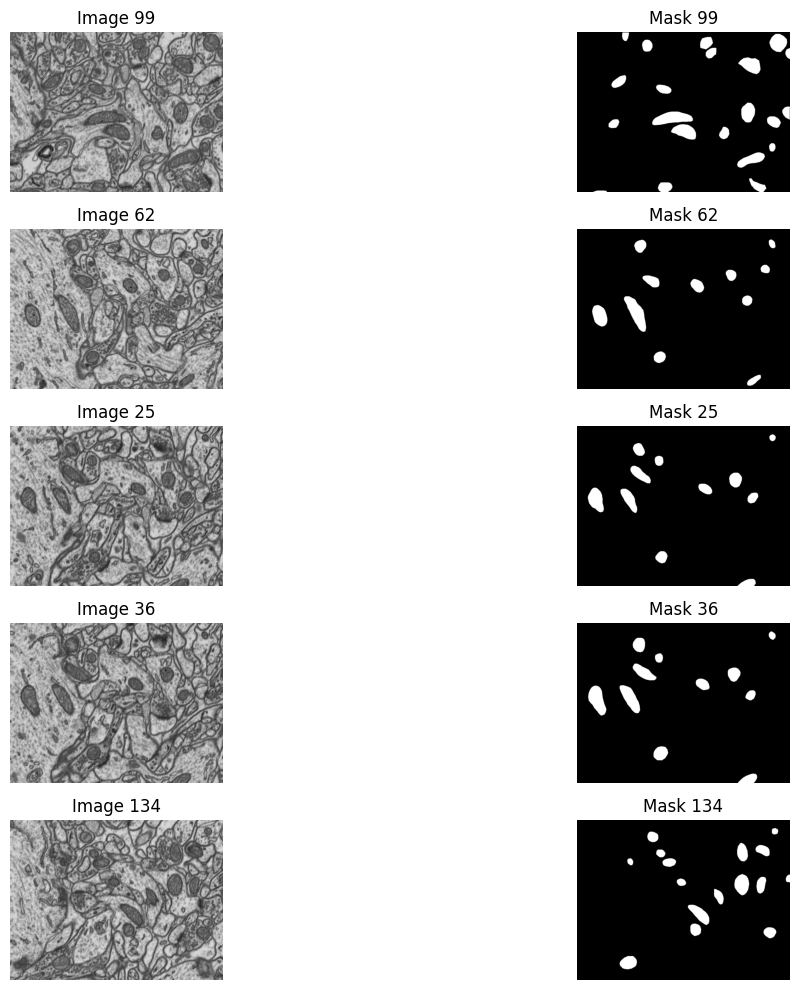

In [14]:

import random


# Dataset paths
TRAIN_IMAGES = "/content/dataset/train/images"
TRAIN_MASKS  = "/content/dataset/train/masks"

# Get image and mask paths
image_paths = sorted(glob(os.path.join(TRAIN_IMAGES, "*")))
mask_paths = sorted(glob(os.path.join(TRAIN_MASKS, "*")))

# Select 5 random samples
num_samples = 5
indices = random.sample(range(len(image_paths)), num_samples)

# Display images and masks
plt.figure(figsize=(15, 10))

for i, idx in enumerate(indices):

    # Read image
    image = cv2.imread(image_paths[idx], cv2.IMREAD_GRAYSCALE)

    # Read mask
    mask = cv2.imread(mask_paths[idx], cv2.IMREAD_GRAYSCALE)

    # Original image
    plt.subplot(num_samples, 2, 2*i + 1)
    plt.imshow(image, cmap='gray')
    plt.title(f"Image {idx}")
    plt.axis('off')

    # Corresponding mask
    plt.subplot(num_samples, 2, 2*i + 2)
    plt.imshow(mask, cmap='gray')
    plt.title(f"Mask {idx}")
    plt.axis('off')

plt.tight_layout()
plt.show()

**Step 8: Train Validation Split**

In [15]:
X_train, X_val, y_train, y_val = train_test_split(
    X, Y,
    test_size=0.2,
    random_state=42
)

**Step 9: U-Net Architecture**

In [16]:
def conv_block(inputs, filters):

    x = layers.Conv2D(filters, 3, padding='same')(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters, 3, padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)

    return x


def encoder_block(inputs, filters):

    x = conv_block(inputs, filters)
    p = layers.MaxPooling2D((2,2))(x)

    return x, p


def decoder_block(inputs, skip, filters):

    x = layers.Conv2DTranspose(
        filters,
        (2,2),
        strides=2,
        padding='same'
    )(inputs)

    x = layers.Concatenate()([x, skip])
    x = conv_block(x, filters)

    return x


def build_unet(input_shape=(256,256,1)):

    inputs = layers.Input(input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 64)
    s2, p2 = encoder_block(p1, 128)
    s3, p3 = encoder_block(p2, 256)
    s4, p4 = encoder_block(p3, 512)

    # Bridge
    b1 = conv_block(p4, 1024)

    # Decoder
    d1 = decoder_block(b1, s4, 512)
    d2 = decoder_block(d1, s3, 256)
    d3 = decoder_block(d2, s2, 128)
    d4 = decoder_block(d3, s1, 64)

    outputs = layers.Conv2D(
        1,
        (1,1),
        activation='sigmoid'
    )(d4)

    model = Model(inputs, outputs)

    return model

**Step 10: Dice Coefficient**

In [17]:
def dice_coef(y_true, y_pred):

    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    intersection = tf.keras.backend.sum(
        y_true * y_pred
    )

    return (
        2. * intersection + 1e-7
    ) / (
        tf.keras.backend.sum(y_true) +
        tf.keras.backend.sum(y_pred) +
        1e-7
    )


def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

**Step 11: Build Model**

In [18]:
model = build_unet()

model.compile(
    optimizer='adam',
    loss=dice_loss,
    metrics=[
        dice_coef,
        'accuracy'
    ]
)

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 1)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        640 │ input_layer[0][0] │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        256 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │     36,928 │ activation[0][0]  │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        256 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     73,856 │ max_pooling2d[0]… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │    147,584 │ activation_2[0][… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        512 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │    295,168 │ max_pooling2d_1[… │
│                     │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │      1,024 │ conv2d_4[0][0]  

 Total params: 31,054,145 (118.46 MB)

 Trainable params: 31,042,369 (118.42 MB)

 Non-trainable params: 11,776 (46.00 KB)

**Step 12: Callbacks**

In [19]:
checkpoint = ModelCheckpoint(
    "best_unet.h5",
    monitor='val_dice_coef',
    mode='max',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

**Step 13: Train Model**

In [20]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=8,
    callbacks=[
        checkpoint,
        earlystop
    ]
)

Epoch 1/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 38s/step - accuracy: 0.7747 - dice_coef: 0.2751 - loss: 0.7252 
Epoch 1: val_dice_coef improved from None to 0.09991, saving model to best_unet.h5



Epoch 1: finished saving model to best_unet.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 740s 43s/step - accuracy: 0.8727 - dice_coef: 0.3724 - loss: 0.6322 - val_accuracy: 0.0682 - val_dice_coef: 0.0999 - val_loss: 0.8971
Epoch 2/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 38s/step - accuracy: 0.9740 - dice_coef: 0.5723 - loss: 0.4278 
Epoch 2: val_dice_coef did not improve from 0.09991
17/17 ━━━━━━━━━━━━━━━━━━━━ 753s 44s/step - accuracy: 0.9784 - dice_coef: 0.5984 - loss: 0.4024 - val_accuracy: 0.0521 - val_dice_coef: 0.0981 - val_loss: 0.8989
Epoch 3/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 39s/step - accuracy: 0.9841 - dice_coef: 0.6851 - loss: 0.3150 
Epoch 3: val_dice_coef did not improve from 0.09991
17/17 ━━━━━━━━━━━━━━━━━━━━ 740s 44s/step - accuracy: 0.9849 - dice_coef: 0.7063 - loss: 0.2952 - val_accuracy: 0.0526 - val_dice_coef: 0.0981 - val_loss: 0.8988
Epoch 4/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 40s/step - accuracy: 0.9878 - dice_coef: 0.7665 - loss: 0.2335 
Epoch 4: val_dice_coef did not improve from 0.0999


Epoch 5: finished saving model to best_unet.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 768s 45s/step - accuracy: 0.9899 - dice_coef: 0.8353 - loss: 0.1650 - val_accuracy: 0.3437 - val_dice_coef: 0.1064 - val_loss: 0.8908
Epoch 6/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 37s/step - accuracy: 0.9913 - dice_coef: 0.8639 - loss: 0.1361 
Epoch 6: val_dice_coef improved from 0.10640 to 0.10801, saving model to best_unet.h5



Epoch 6: finished saving model to best_unet.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 707s 42s/step - accuracy: 0.9911 - dice_coef: 0.8693 - loss: 0.1312 - val_accuracy: 0.2064 - val_dice_coef: 0.1080 - val_loss: 0.8895
Epoch 7/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 36s/step - accuracy: 0.9913 - dice_coef: 0.8877 - loss: 0.1122 
Epoch 7: val_dice_coef improved from 0.10801 to 0.10974, saving model to best_unet.h5



Epoch 7: finished saving model to best_unet.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 704s 42s/step - accuracy: 0.9917 - dice_coef: 0.8909 - loss: 0.1089 - val_accuracy: 0.8803 - val_dice_coef: 0.1097 - val_loss: 0.8854
Epoch 8/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 36s/step - accuracy: 0.9920 - dice_coef: 0.9053 - loss: 0.0947 
Epoch 8: val_dice_coef did not improve from 0.10974
17/17 ━━━━━━━━━━━━━━━━━━━━ 661s 39s/step - accuracy: 0.9922 - dice_coef: 0.9061 - loss: 0.0943 - val_accuracy: 0.9455 - val_dice_coef: 0.0256 - val_loss: 0.9732
Epoch 9/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 38s/step - accuracy: 0.9928 - dice_coef: 0.9164 - loss: 0.0836 
Epoch 9: val_dice_coef did not improve from 0.10974
17/17 ━━━━━━━━━━━━━━━━━━━━ 709s 41s/step - accuracy: 0.9927 - dice_coef: 0.9182 - loss: 0.0814 - val_accuracy: 0.9456 - val_dice_coef: 0.0168 - val_loss: 0.9831
Epoch 10/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 38s/step - accuracy: 0.9926 - dice_coef: 0.9244 - loss: 0.0756 
Epoch 10: val_dice_coef did not improve from 0.10


Epoch 17: finished saving model to best_unet.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 726s 43s/step - accuracy: 0.9939 - dice_coef: 0.9488 - loss: 0.0513 - val_accuracy: 0.9501 - val_dice_coef: 0.2202 - val_loss: 0.7636
Epoch 18/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 36s/step - accuracy: 0.9939 - dice_coef: 0.9509 - loss: 0.0491 
Epoch 18: val_dice_coef improved from 0.22024 to 0.36945, saving model to best_unet.h5



Epoch 18: finished saving model to best_unet.h5
17/17 ━━━━━━━━━━━━━━━━━━━━ 676s 39s/step - accuracy: 0.9941 - dice_coef: 0.9515 - loss: 0.0487 - val_accuracy: 0.9523 - val_dice_coef: 0.3694 - val_loss: 0.6124
Epoch 19/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 36s/step - accuracy: 0.9945 - dice_coef: 0.9527 - loss: 0.0473 
Epoch 19: val_dice_coef did not improve from 0.36945
17/17 ━━━━━━━━━━━━━━━━━━━━ 668s 39s/step - accuracy: 0.9943 - dice_coef: 0.9533 - loss: 0.0466 - val_accuracy: 0.9490 - val_dice_coef: 0.1284 - val_loss: 0.8508
Epoch 20/20
17/17 ━━━━━━━━━━━━━━━━━━━━ 0s 37s/step - accuracy: 0.9944 - dice_coef: 0.9539 - loss: 0.0461 
Epoch 20: val_dice_coef did not improve from 0.36945
17/17 ━━━━━━━━━━━━━━━━━━━━ 683s 39s/step - accuracy: 0.9943 - dice_coef: 0.9541 - loss: 0.0457 - val_accuracy: 0.9482 - val_dice_coef: 0.0894 - val_loss: 0.8923


In [34]:
# ─── Save model on GDrive ─────────────────────────────────
SAVE_PATH = "/content/drive/MyDrive/UNet_EM_Model"
os.makedirs(SAVE_PATH, exist_ok=True)
model.save(f"{SAVE_PATH}/unet_em_model.h5")

**Step 14: Plot Training Curves**

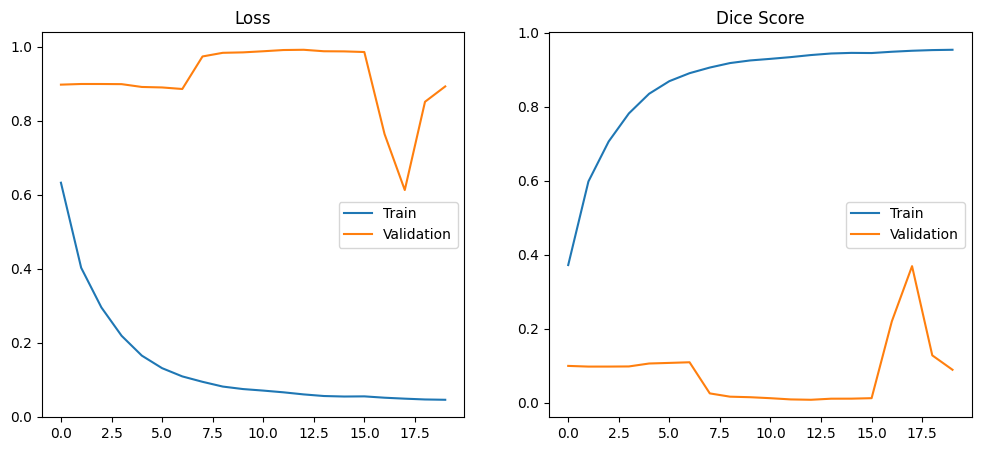

In [21]:
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title("Loss")
plt.legend(["Train","Validation"])

plt.subplot(1,2,2)
plt.plot(history.history['dice_coef'])
plt.plot(history.history['val_dice_coef'])
plt.title("Dice Score")
plt.legend(["Train","Validation"])

plt.show()

**Step 15: Load Test Data**

In [22]:
X_test, Y_test = load_data(
    TEST_IMAGES,
    TEST_MASKS
)

print(X_test.shape)

(165, 256, 256, 1)


**Step 16: Evaluate**

In [23]:
results = model.evaluate(
    X_test,
    Y_test,
    verbose=1
)

print("Test Loss:", results[0])
print("Dice Score:", results[1])
print("Accuracy:", results[2])

6/6 ━━━━━━━━━━━━━━━━━━━━ 210s 34s/step - accuracy: 0.9405 - dice_coef: 0.2312 - loss: 0.7721
Test Loss: 0.7720804214477539
Dice Score: 0.23117180168628693
Accuracy: 0.9405125379562378


**Step 17: Prediction Visualization**

6/6 ━━━━━━━━━━━━━━━━━━━━ 214s 34s/step


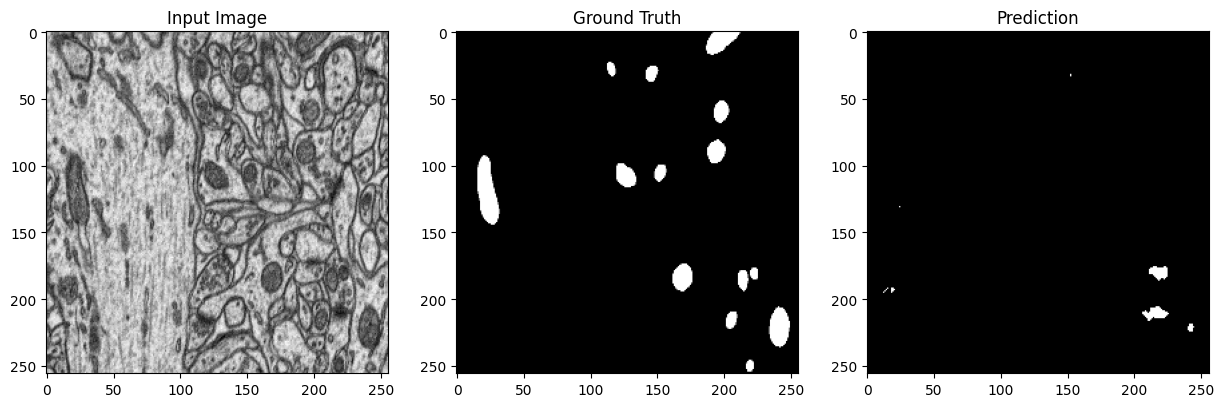

In [24]:
preds = model.predict(X_test)

index = np.random.randint(len(X_test))

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(
    X_test[index].squeeze(),
    cmap='gray'
)
plt.title("Input Image")

plt.subplot(1,3,2)
plt.imshow(
    Y_test[index].squeeze(),
    cmap='gray'
)
plt.title("Ground Truth")

plt.subplot(1,3,3)
plt.imshow(
    (preds[index] > 0.5).squeeze(),
    cmap='gray'
)
plt.title("Prediction")

plt.show()

In [28]:
import gradio as gr
from tensorflow.keras.models import load_model

In [29]:
def dice_coef(y_true, y_pred):

    y_true = tf.keras.backend.flatten(y_true)
    y_pred = tf.keras.backend.flatten(y_pred)

    intersection = tf.keras.backend.sum(y_true * y_pred)

    return (
        2.0 * intersection + 1e-7
    ) / (
        tf.keras.backend.sum(y_true) +
        tf.keras.backend.sum(y_pred) +
        1e-7
    )


def dice_loss(y_true, y_pred):
    return 1 - dice_coef(y_true, y_pred)

In [30]:
MODEL_PATH = "/content/best_unet.h5"

model = load_model(
    MODEL_PATH,
    custom_objects={
        'dice_loss': dice_loss,
        'dice_coef': dice_coef
    }
)

print("Model Loaded Successfully")

Model Loaded Successfully


In [31]:
IMG_SIZE = 256

def segment_image(image):

    # Convert RGB to grayscale if needed
    if len(image.shape) == 3:
        image_gray = cv2.cvtColor(
            image,
            cv2.COLOR_RGB2GRAY
        )
    else:
        image_gray = image

    # Save original
    original = image_gray.copy()

    # Resize
    image_resized = cv2.resize(
        image_gray,
        (IMG_SIZE, IMG_SIZE)
    )

    # Normalize
    image_resized = image_resized / 255.0

    # Add dimensions
    image_input = np.expand_dims(
        image_resized,
        axis=(0, -1)
    )

    # Prediction
    pred = model.predict(
        image_input,
        verbose=0
    )

    # Binary Mask
    mask = (pred[0] > 0.5).astype(np.uint8)

    mask = mask.squeeze()

    # Resize back to original image size
    mask = cv2.resize(
        mask,
        (original.shape[1],
         original.shape[0]),
        interpolation=cv2.INTER_NEAREST
    )

    mask_display = mask * 255

    # Create Overlay
    original_rgb = cv2.cvtColor(
        original,
        cv2.COLOR_GRAY2RGB
    )

    overlay = original_rgb.copy()

    overlay[mask == 1] = [255, 0, 0]

    overlay = cv2.addWeighted(
        original_rgb,
        0.7,
        overlay,
        0.3,
        0
    )

    return mask_display, overlay

In [32]:
interface = gr.Interface(
    fn=segment_image,

    inputs=gr.Image(
        type="numpy",
        label="Upload EM Image"
    ),

    outputs=[
        gr.Image(label="Predicted Mask"),
        gr.Image(label="Overlay Result")
    ],

    title="Electron Microscopy Segmentation Using U-Net",

    description="""
    Upload an Electron Microscopy image.
    The trained U-Net model will generate a segmentation mask
    and overlay it on the original image.
    """
)

In [33]:
interface.launch(
    share=True,
    debug=True
)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://dc474dcf3b68364f5a.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://dc474dcf3b68364f5a.gradio.live
